# Evaluation: Logic-Accelerated DPN Discovery

This notebook evaluates the DPN discovery pipeline on **synthetic test cases** of increasing complexity.
Each test case targets a specific aspect of process discovery:

| # | Test Case | Control Flow | Guards | Updates | Complexity |
|---|-----------|-------------|--------|---------|------------|
| 1 | Simple Sequence | A → B → C | `True` | `x := x + 1` | ★☆☆ |
| 2 | XOR Split/Join | A → {B \| C} → D | `score ≥ 50` / `score < 50` | — | ★★☆ |
| 3 | Loop | A → B ↺ → C | `i < 3` / `i ≥ 3` | `i := i + 1` | ★★☆ |
| 4 | Concurrency (AND) | A → (B ∥ C) → D | `True` | `x := x + v`, `y := y + v` | ★★★ |
| 5 | Multi-variable XOR | A → {B \| C \| D} → E | compound (`amount`, `risk`) | `amount := amount · 1.1` | ★★★ |
| 6 | Combined: Loop + XOR + Updates | nested structures | multi-variable | arithmetic | ★★★★ |

For each test case we:
1. Define the **ground-truth** process model (expected structure, guards, updates)
2. Generate a small **synthetic event log** (few traces)
3. Run the **full discovery pipeline**
4. **Visualize** the discovered DPN and intermediate EFSM
5. **Assess** correctness of discovered guards and update functions

In [21]:
# ── Imports & Setup ──────────────────────────────────────────────────────
import logging
from IPython.display import display, Image, HTML

from dpn_discovery.models import Event, Trace, EventLog, MergeStrategy
from dpn_discovery.preprocessing import parse_event_log
from dpn_discovery.pipeline import run_pipeline, run_pipeline_full
from dpn_discovery.dpn_transform import dpn_to_pnml
from dpn_discovery.smt import get_solver, set_solver
from dpn_discovery.smt.yices2_solver import Yices2SMTSolver
from dpn_discovery.visualization import DPNVisualizer, VisualizerSettings

# Use Yices2 as the SMT backend
set_solver(Yices2SMTSolver())
smt = get_solver()

# Logging: show pipeline steps
logging.basicConfig(level=logging.INFO, format="%(levelname)-8s %(message)s", force=True)

# Visualization settings (SVG for inline display)
viz_settings = VisualizerSettings(output_format="svg", rankdir="LR")
viz = DPNVisualizer(viz_settings)

In [22]:
# Force-reload updated modules
import importlib
import dpn_discovery.guard_synthesis
import dpn_discovery.pipeline
importlib.reload(dpn_discovery.guard_synthesis)
importlib.reload(dpn_discovery.pipeline)
from dpn_discovery.pipeline import run_pipeline, run_pipeline_full
print("Modules reloaded.")

Modules reloaded.


In [23]:
# ── Helper functions ─────────────────────────────────────────────────────

def make_log(raw_traces: list[list[tuple[str, dict]]]) -> EventLog:
    """Build an EventLog from a compact list-of-lists representation.
    
    Each trace is a list of (activity, payload_dict) tuples.
    """
    traces = []
    activities = set()
    variables = set()
    for raw in raw_traces:
        events = []
        for act, payload in raw:
            activities.add(act)
            variables.update(payload.keys())
            events.append(Event(activity=act, payload=payload))
        traces.append(Trace(events=events))
    return EventLog(traces=traces, activities=activities, variables=variables)


def show_results(name: str, log: EventLog, **pipeline_kwargs):
    """Run pipeline, print summary, and display DPN + EFSM visualizations."""
    print(f"\n{'='*70}")
    print(f"  {name}")
    print(f"{'='*70}")
    print(f"  Traces: {len(log.traces)}  |  Activities: {log.activities}  |  Variables: {log.variables}")
    print()

    pta, efsm, dpn = run_pipeline_full(log, **pipeline_kwargs)

    print(f"\n  PTA  : {len(pta.states)} states, {len(pta.transitions)} transitions")
    print(f"  EFSM : {len(efsm.states)} states, {len(efsm.transitions)} transitions")
    print(f"  DPN  : {len(dpn.places)} places, {len(dpn.transitions)} transitions")

    # Print discovered guards & updates
    print(f"\n  Discovered annotations:")
    for t in dpn.transitions:
        activity = t.name
        guard_str = smt.expr_to_string(t.guard) if t.guard is not None else "True"
        print(f"    {activity:30s}  guard = {guard_str}")
        if t.update_rule:
            for var, expr in sorted(t.update_rule.items()):
                print(f"    {'':30s}  {var}' := {smt.expr_to_string(expr)}")
    print()

    # Render visualizations inline
    efsm_dot = viz.render_efsm(efsm, title=f"{name} — EFSM")
    dpn_dot = viz.render_dpn(dpn, title=f"{name} — DPN")

    display(HTML(f"<h4>{name} — Merged EFSM</h4>"))
    display(efsm_dot)
    display(HTML(f"<h4>{name} — Discovered DPN</h4>"))
    display(dpn_dot)

    return pta, efsm, dpn

### Pipeline Parameter Choices

**`min_merge_score = 1` (EDSM threshold $k$):** The EDSM scoring function counts shared 
outgoing activity labels between two candidate states. With the default $k = 0$, states 
sharing *zero* outgoing labels still qualify for merging (score $0 \geq 0$). This leads to 
cascading over-merging — once a state accumulates multiple activities, the consistency check 
becomes vacuously true, and the entire EFSM collapses into a **single-state flower net**. 
Setting $k = 1$ requires at least one shared outgoing activity as structural evidence.

**`MergeStrategy.BLUE_FRINGE` for sequential / XOR / loop test cases:** Blue-Fringe merging 
(Walkinshaw et al. Alg. 1 & 2) shares prefixes purely by activity label, placing the branching 
point at the state where activities diverge (e.g., B vs C from the same state). This ensures 
guard synthesis has access to the **pre-state data** at the decision point. MINT classifiers 
would split the prefix earlier (at the A level) where the pre-state is empty, preventing 
meaningful guard discovery.

**`MergeStrategy.NONE` for concurrency (TC4):** MINT and Blue-Fringe both assume deterministic 
next-event prediction, which is violated when the same data state can lead to either ordering 
of concurrent activities. By keeping the full PTA, bisimulation reduction merges only truly 
equivalent states, and the **theory of regions** (Cortadella et al.) derives the AND-split/join 
places from the interleaving structure.

---
## TC 1 — Simple Sequence (★☆☆)

**Ground truth:**  
```
A  →  B  →  C
```

- **Variables:** `x` (integer counter)  
- **Guards:** all `True` (no branching)  
- **Updates:** `x := x + 1` at each step  

**Purpose:** Baseline — verify the pipeline discovers a pure sequence with a simple counter update.

INFO     Step 1  >  Using pre-loaded EventLog
INFO              Activities = {'B', 'C', 'A'}  |  Variables = {'x'}  |  Traces = 3
INFO     Step 2  >  Classifier training skipped (strategy=BLUE_FRINGE)
INFO     Step 3  >  Building Prefix Tree Acceptor
INFO              States = 4  |  Transitions = 3
INFO     Step 4  >  State merging (strategy=BLUE_FRINGE)
WARNING    Blue-Fringe merging is available but MINT is recommended. Blue-Fringe does not use classifiers and may under-merge.
INFO       Merge loop done: 3 iterations, 0 merges, 4 → 4 states
INFO              States = 4 -> 4  |  Transitions = 3 -> 3
INFO     Step 4b >  Bisimulation-based state reduction
INFO              States = 4 -> 4  |  Transitions = 3
INFO     Step 5  >  Synthesising guards (PHOG-accelerated SAT)
INFO     Guard synthesis: 4 states, 3 transitions, 1 variables
INFO              Guards synthesised
INFO     Step 6  >  Synthesising postconditions (abduction)
INFO     Postcondition synthesis: 3 transitions, 1 variables


  TC1: Simple Sequence
  Traces: 3  |  Activities: {'B', 'C', 'A'}  |  Variables: {'x'}


  PTA  : 4 states, 3 transitions
  EFSM : 4 states, 3 transitions
  DPN  : 4 places, 3 transitions

  Discovered annotations:
    t_A_1                           guard = true
    t_B_2                           guard = true
                                    x' := (+ 1 x)
    t_C_3                           guard = true
                                    x' := (+ 1 x)



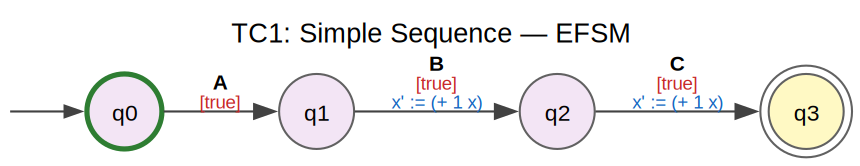

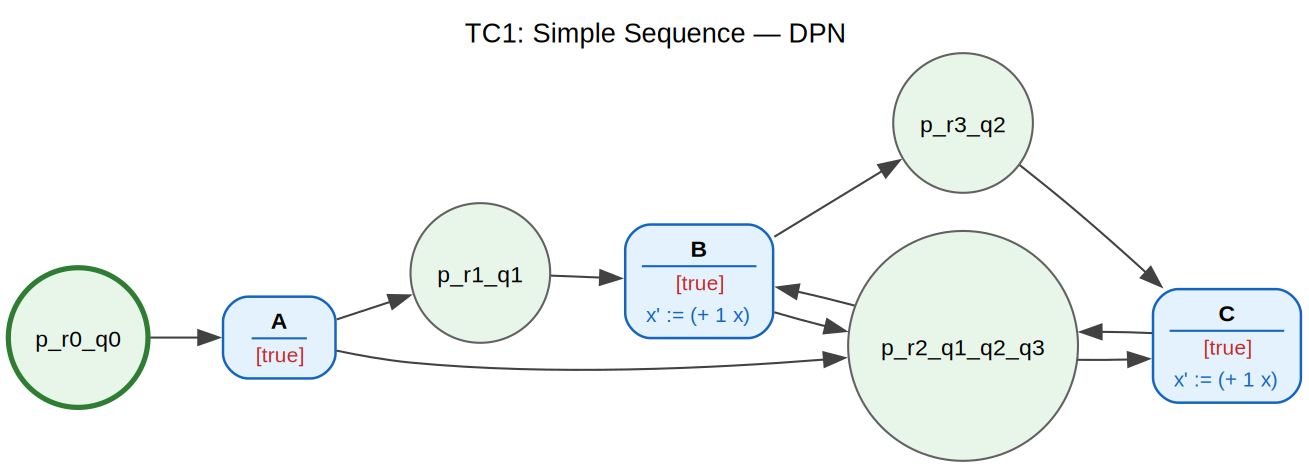

In [24]:
tc1_log = make_log([
    # Trace 1:  x increments 0 → 1 → 2
    [("A", {"x": 0}), ("B", {"x": 1}), ("C", {"x": 2})],
    # Trace 2:  same structure, different initial value
    [("A", {"x": 5}), ("B", {"x": 6}), ("C", {"x": 7})],
    # Trace 3
    [("A", {"x": 10}), ("B", {"x": 11}), ("C", {"x": 12})],
])

_, _, tc1_dpn = show_results(
    "TC1: Simple Sequence", tc1_log,
    merge_strategy=MergeStrategy.BLUE_FRINGE, min_merge_score=1,
)

**Expected result:**  
- 3 transitions (A, B, C) connected sequentially  
- All guards = `True`  
- Update: `x' := x + 1` on every transition  

---
## TC 2 — XOR Split / Join (★★☆)

**Ground truth:**  
```
        ┌─ B ─┐
  A  ──►│     │──► D
        └─ C ─┘
```

- **Variables:** `score` (integer)  
- **Guards:** B: `score ≥ 50` (pass), C: `score < 50` (fail)  
- **Updates:** identity (no variable changes)  

**Purpose:** Test exclusive-choice discovery and guard synthesis on a single variable threshold.

INFO     Step 1  >  Using pre-loaded EventLog
INFO              Activities = {'B', 'D', 'C', 'A'}  |  Variables = {'score'}  |  Traces = 6
INFO     Step 2  >  Classifier training skipped (strategy=BLUE_FRINGE)
INFO     Step 3  >  Building Prefix Tree Acceptor
INFO              States = 6  |  Transitions = 5
INFO     Step 4  >  State merging (strategy=BLUE_FRINGE)
WARNING    Blue-Fringe merging is available but MINT is recommended. Blue-Fringe does not use classifiers and may under-merge.
INFO       Merge loop done: 4 iterations, 1 merges, 6 → 4 states
INFO              States = 6 -> 4  |  Transitions = 5 -> 4
INFO     Step 4b >  Bisimulation-based state reduction
INFO              States = 4 -> 4  |  Transitions = 4
INFO     Step 5  >  Synthesising guards (PHOG-accelerated SAT)
INFO     Guard synthesis: 4 states, 4 transitions, 1 variables
INFO       [2/4] State q1: pairwise cross-activity guards for ['B', 'C']
INFO       Partition verified (cross-activity): 2 guards are pairwise disjo


  TC2: XOR Split/Join
  Traces: 6  |  Activities: {'B', 'D', 'C', 'A'}  |  Variables: {'score'}


  PTA  : 6 states, 5 transitions
  EFSM : 4 states, 4 transitions
  DPN  : 3 places, 4 transitions

  Discovered annotations:
    t_A_1                           guard = true
    t_B_2                           guard = (< (+ 99/2 (* -1 score)) 0)
                                    score' := score
    t_C_3                           guard = (>= (+ 99/2 (* -1 score)) 0)
                                    score' := score
    t_D_4                           guard = true
                                    score' := score



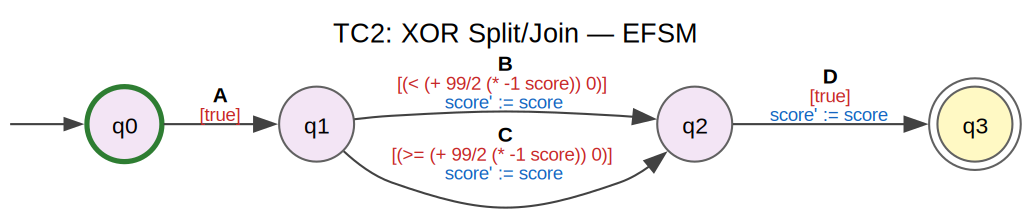

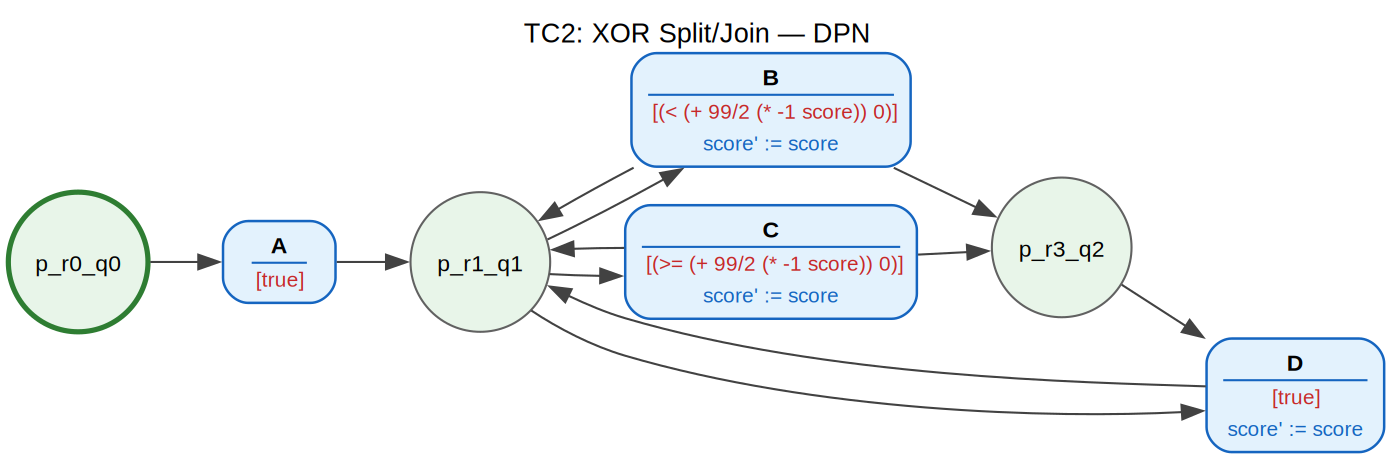

In [25]:
tc2_log = make_log([
    # Pass branch (score >= 50)
    [("A", {"score": 80}),  ("B", {"score": 80}),  ("D", {"score": 80})],
    [("A", {"score": 50}),  ("B", {"score": 50}),  ("D", {"score": 50})],
    [("A", {"score": 95}),  ("B", {"score": 95}),  ("D", {"score": 95})],
    # Fail branch (score < 50)
    [("A", {"score": 30}),  ("C", {"score": 30}),  ("D", {"score": 30})],
    [("A", {"score": 10}),  ("C", {"score": 10}),  ("D", {"score": 10})],
    [("A", {"score": 49}),  ("C", {"score": 49}),  ("D", {"score": 49})],
])

_, _, tc2_dpn = show_results(
    "TC2: XOR Split/Join", tc2_log,
    merge_strategy=MergeStrategy.BLUE_FRINGE, min_merge_score=1,
)

**Expected result:**  
- 4 transitions: A, B, C, D  
- Guard(B) ≈ `score ≥ 50`  
- Guard(C) ≈ `score < 50`  
- No update functions  

---
## TC 3 — Loop with Counter (★★☆)

**Ground truth:**  
```
  A  →  B ↺  →  C
         │
         └─ loop back if i < 3
```

- **Variables:** `i` (loop counter)  
- **Guards:** loop-back: `i < 3`, exit: `i ≥ 3`  
- **Updates:** `i := i + 1` on each B execution  

**Purpose:** Test loop discovery, loop guard synthesis, and counter update detection.

INFO     Step 1  >  Using pre-loaded EventLog
INFO              Activities = {'B', 'C', 'A'}  |  Variables = {'i'}  |  Traces = 4
INFO     Step 2  >  Classifier training skipped (strategy=BLUE_FRINGE)
INFO     Step 3  >  Building Prefix Tree Acceptor
INFO              States = 8  |  Transitions = 7
INFO     Step 4  >  State merging (strategy=BLUE_FRINGE)
WARNING    Blue-Fringe merging is available but MINT is recommended. Blue-Fringe does not use classifiers and may under-merge.
INFO       Merge loop done: 3 iterations, 1 merges, 8 → 3 states
INFO              States = 8 -> 3  |  Transitions = 7 -> 3
INFO     Step 4b >  Bisimulation-based state reduction
INFO              States = 3 -> 3  |  Transitions = 3
INFO     Step 5  >  Synthesising guards (PHOG-accelerated SAT)
INFO     Guard synthesis: 3 states, 3 transitions, 1 variables
INFO       [2/3] State q1: pairwise cross-activity guards for ['B', 'C']
INFO       Partition verified (cross-activity): 2 guards are pairwise disjoint and e


  TC3: Loop with Counter
  Traces: 4  |  Activities: {'B', 'C', 'A'}  |  Variables: {'i'}


  PTA  : 8 states, 7 transitions
  EFSM : 3 states, 3 transitions
  DPN  : 2 places, 3 transitions

  Discovered annotations:
    t_A_1                           guard = true
    t_B_2                           guard = (>= (+ 5/2 (* -1 i)) 0)
                                    i' := (+ 1 i)
    t_C_3                           guard = (< (+ 5/2 (* -1 i)) 0)
                                    i' := i



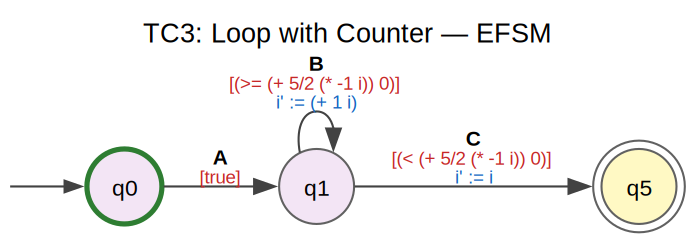

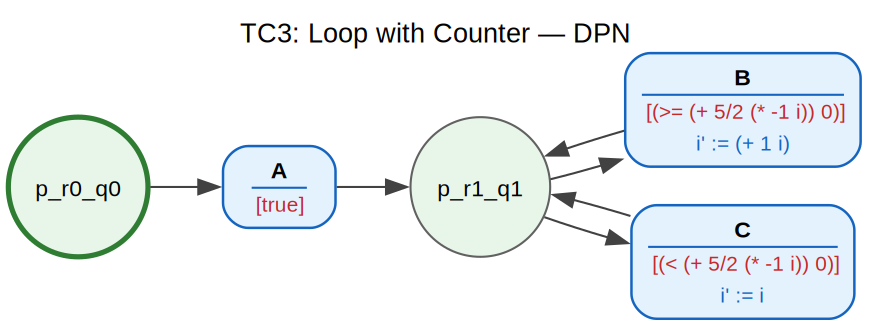

In [26]:
tc3_log = make_log([
    # 3 iterations of B: i goes 0 → 1 → 2 → 3 → exit
    [("A", {"i": 0}), ("B", {"i": 1}), ("B", {"i": 2}), ("B", {"i": 3}), ("C", {"i": 3})],
    # Duplicate trace (reinforces the pattern)
    [("A", {"i": 0}), ("B", {"i": 1}), ("B", {"i": 2}), ("B", {"i": 3}), ("C", {"i": 3})],
    # Shorter loop: 2 iterations
    [("A", {"i": 1}), ("B", {"i": 2}), ("B", {"i": 3}), ("C", {"i": 3})],
    # Minimal: 1 iteration then exit
    [("A", {"i": 2}), ("B", {"i": 3}), ("C", {"i": 3})],
])

_, _, tc3_dpn = show_results(
    "TC3: Loop with Counter", tc3_log,
    merge_strategy=MergeStrategy.BLUE_FRINGE, min_merge_score=1,
)

**Expected result:**  
- Self-loop on B (or equivalent cyclic structure)  
- Guard(B→B) ≈ `i < 3`, Guard(B→C) ≈ `i ≥ 3`  
- Update: `i' := i + 1` on B  

---
## TC 4 — Concurrency / AND Split-Join (★★★)

**Ground truth:**  
```
        ┌─ B ─┐
  A  ──►│     │──► D
        └─ C ─┘
  (B ∥ C — parallel, not exclusive)
```

- **Variables:** `x`, `y`  
- **Guards:** all `True`  
- **Updates:** B sets `x := x + 1`, C sets `y := y + 1`  

Evidence for concurrency: B and C appear in **both orderings** across traces.  

**Purpose:** Test whether the pipeline can distinguish concurrency from exclusive choice.

> **Strategy note:** We use `MergeStrategy.NONE` here because MINT classifiers assume
> deterministic next-event prediction, which is violated by concurrency (same data state
> can lead to either B-first or C-first). By keeping the full PTA, bisimulation reduction
> merges only truly equivalent states, and the **theory of regions** (Cortadella et al.)
> derives the AND-split/join places from the interleaving structure.

INFO     Step 1  >  Using pre-loaded EventLog
INFO              Activities = {'B', 'D', 'C', 'A'}  |  Variables = {'x', 'y'}  |  Traces = 6
INFO     Step 2  >  Classifier training skipped (strategy=NONE)
INFO     Step 3  >  Building Prefix Tree Acceptor
INFO              States = 8  |  Transitions = 7
INFO     Step 4  >  State merging (strategy=NONE)
INFO     Merging disabled (strategy=NONE)
INFO              States = 8 -> 8  |  Transitions = 7 -> 7
INFO     Step 4b >  Bisimulation-based state reduction
INFO       Bisimulation reduction: 2 merges → 6 states
INFO              States = 8 -> 6  |  Transitions = 6
INFO     Step 5  >  Synthesising guards (PHOG-accelerated SAT)
INFO     Guard synthesis: 6 states, 6 transitions, 2 variables
INFO       [2/6] State q1: pairwise cross-activity guards for ['B', 'C']



  TC4: Concurrency (AND Split/Join)
  Traces: 6  |  Activities: {'B', 'D', 'C', 'A'}  |  Variables: {'x', 'y'}



INFO              Guards synthesised
INFO     Step 6  >  Synthesising postconditions (abduction)
INFO     Postcondition synthesis: 6 transitions, 2 variables
INFO       [1/6] q0 → q1 (A): 6 observation pairs
INFO       [2/6] q1 → q2 (B): 3 observation pairs
INFO       [3/6] q2 → q3 (C): 3 observation pairs
INFO       [4/6] q3 → q4 (D): 6 observation pairs
INFO       [5/6] q1 → q5 (C): 3 observation pairs
INFO       [6/6] q5 → q3 (B): 3 observation pairs
INFO              Postconditions synthesised
INFO     Step 7  >  Region-based EFSM -> DPN (Cortadella et al. S4)
INFO       Region synthesis: |S| = 6, |E| = 4, |T| = 6
INFO         Iteration 1: 2 pre-regions + 2 complements = 4 total regions
INFO         Excitation closure violated for: ['B', 'D', 'C'] -- splitting labels
INFO       Label split (A.5'): B -> 2 sub-events
INFO       Label split (A.5'): C -> 2 sub-events
INFO         Iteration 2: 5 pre-regions + 5 complements = 10 total regions
INFO         Excitation closure satisfied.
IN


  PTA  : 8 states, 7 transitions
  EFSM : 6 states, 6 transitions
  DPN  : 6 places, 6 transitions

  Discovered annotations:
    t_A_1                           guard = true
    t_B_2                           guard = true
                                    x' := (+ 1 x)
                                    y' := y
    t_B_3                           guard = true
                                    x' := (+ 1 x)
                                    y' := y
    t_C_4                           guard = true
                                    x' := x
                                    y' := (+ 1 y)
    t_C_5                           guard = true
                                    x' := x
                                    y' := (+ 1 y)
    t_D_6                           guard = true
                                    x' := x
                                    y' := y



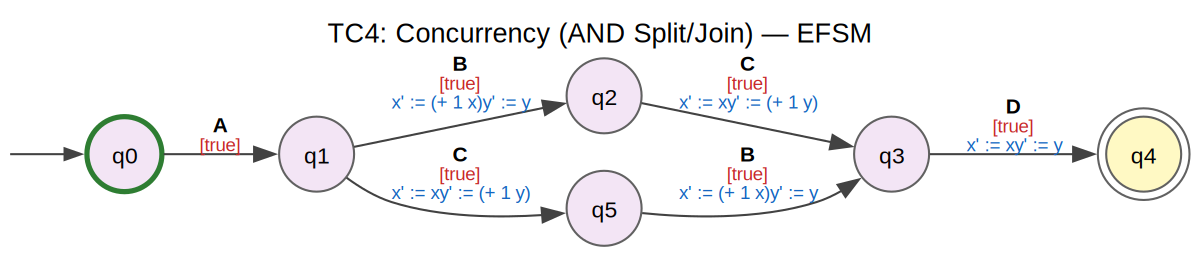

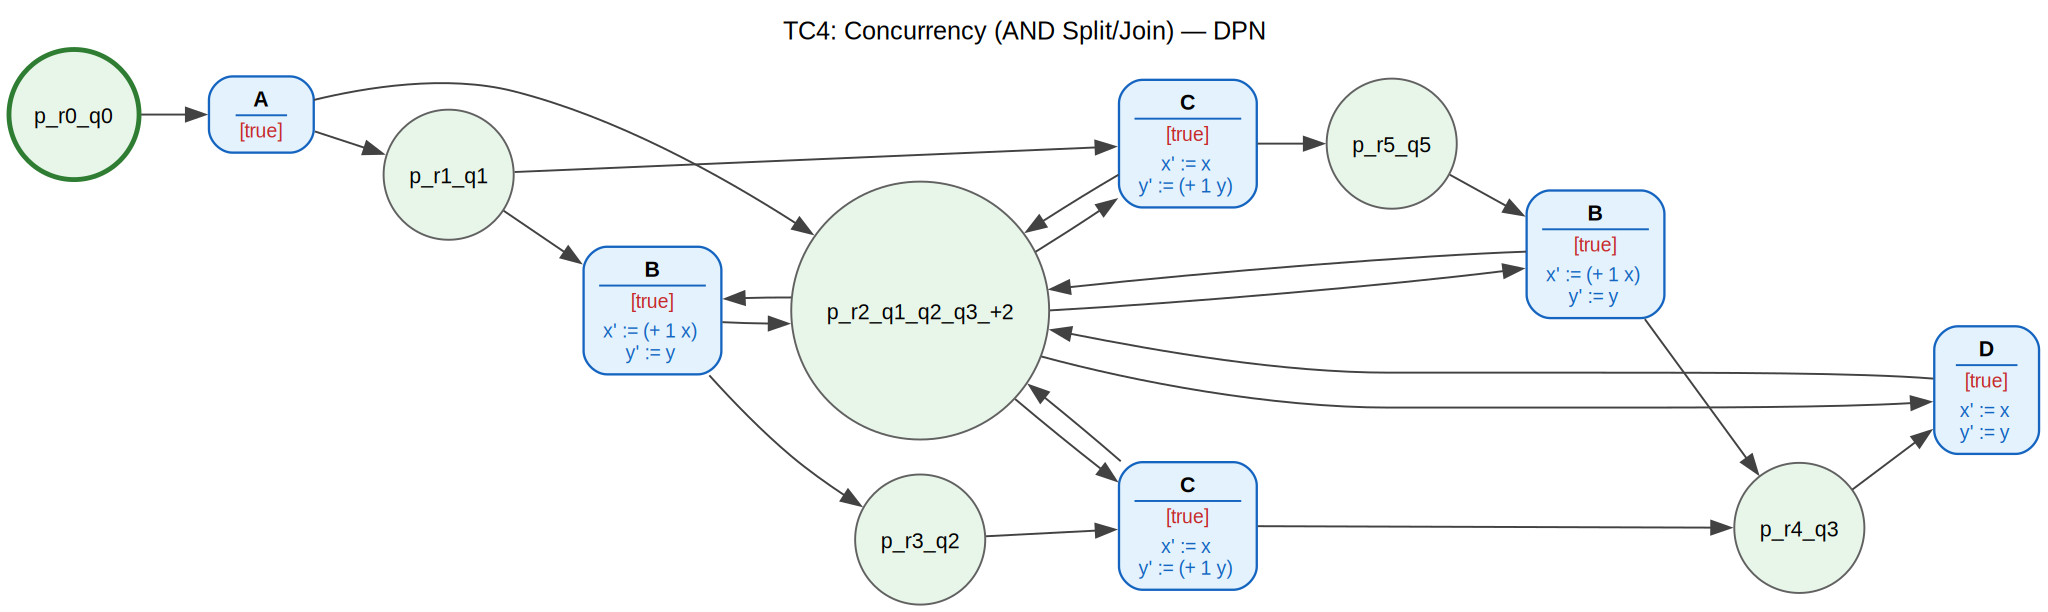

In [27]:
tc4_log = make_log([
    # B before C
    [("A", {"x": 0, "y": 0}), ("B", {"x": 1, "y": 0}), ("C", {"x": 1, "y": 1}), ("D", {"x": 1, "y": 1})],
    [("A", {"x": 0, "y": 0}), ("B", {"x": 1, "y": 0}), ("C", {"x": 1, "y": 1}), ("D", {"x": 1, "y": 1})],
    # C before B
    [("A", {"x": 0, "y": 0}), ("C", {"x": 0, "y": 1}), ("B", {"x": 1, "y": 1}), ("D", {"x": 1, "y": 1})],
    [("A", {"x": 0, "y": 0}), ("C", {"x": 0, "y": 1}), ("B", {"x": 1, "y": 1}), ("D", {"x": 1, "y": 1})],
    # More variation
    [("A", {"x": 5, "y": 5}), ("B", {"x": 6, "y": 5}), ("C", {"x": 6, "y": 6}), ("D", {"x": 6, "y": 6})],
    [("A", {"x": 5, "y": 5}), ("C", {"x": 5, "y": 6}), ("B", {"x": 6, "y": 6}), ("D", {"x": 6, "y": 6})],
])

# Use NONE strategy: skip merging, rely on bisimulation + regions for concurrency
_, _, tc4_dpn = show_results(
    "TC4: Concurrency (AND Split/Join)", tc4_log,
    merge_strategy=MergeStrategy.NONE,
)

**Expected result:**  
- AND-split after A, AND-join before D (parallel places for B and C)  
- All guards = `True`  
- Update(B): `x' := x + 1`  
- Update(C): `y' := y + 1`  

---
## TC 5 — Multi-Variable XOR with Compound Guards (★★★)

**Ground truth:**  
```
        ┌─ B ─┐
  A  ──►├─ C ─┤──► E
        └─ D ─┘
```

- **Variables:** `amount` (int), `risk` (int)  
- **Guards:**  
  - B (approve): `amount ≤ 1000`  
  - C (review):  `amount > 1000 ∧ risk < 5`  
  - D (reject):  `amount > 1000 ∧ risk ≥ 5`  
- **Updates:** B: `amount' := amount + 100` (fee), C/D: identity  

**Purpose:** Test multi-way XOR with compound guards over two variables and a simple arithmetic update.

INFO     Step 1  >  Using pre-loaded EventLog
INFO              Activities = {'D', 'B', 'A', 'C', 'E'}  |  Variables = {'risk', 'amount'}  |  Traces = 9
INFO     Step 2  >  Classifier training skipped (strategy=BLUE_FRINGE)
INFO     Step 3  >  Building Prefix Tree Acceptor
INFO              States = 8  |  Transitions = 7
INFO     Step 4  >  State merging (strategy=BLUE_FRINGE)
WARNING    Blue-Fringe merging is available but MINT is recommended. Blue-Fringe does not use classifiers and may under-merge.
INFO       Merge loop done: 5 iterations, 2 merges, 8 → 4 states
INFO              States = 8 -> 4  |  Transitions = 7 -> 5
INFO     Step 4b >  Bisimulation-based state reduction
INFO              States = 4 -> 4  |  Transitions = 5
INFO     Step 5  >  Synthesising guards (PHOG-accelerated SAT)
INFO     Guard synthesis: 4 states, 5 transitions, 2 variables
INFO       [2/4] State q1: pairwise cross-activity guards for ['B', 'C', 'D']



  TC5: Multi-Variable XOR
  Traces: 9  |  Activities: {'D', 'B', 'A', 'C', 'E'}  |  Variables: {'risk', 'amount'}



INFO       Partition verified (cross-activity): 3 guards are pairwise disjoint and exhaustive
INFO              Guards synthesised
INFO     Step 6  >  Synthesising postconditions (abduction)
INFO     Postcondition synthesis: 5 transitions, 2 variables
INFO       [1/5] q0 → q1 (A): 9 observation pairs
INFO       [2/5] q1 → q2 (B): 3 observation pairs
INFO       [3/5] q2 → q3 (E): 9 observation pairs
INFO       [4/5] q1 → q2 (C): 3 observation pairs
INFO       [5/5] q1 → q2 (D): 3 observation pairs
INFO              Postconditions synthesised
INFO     Step 7  >  Region-based EFSM -> DPN (Cortadella et al. S4)
INFO       Region synthesis: |S| = 4, |E| = 5, |T| = 5
INFO         Iteration 1: 3 pre-regions + 3 complements = 6 total regions
INFO         Excitation closure satisfied.
INFO         Irredundant cover: 4 regions (from 6 total)
INFO         DPN: 4 places, 5 transitions
INFO              Places = 4  |  Transitions = 5
INFO     Step 7b >  Post-synthesis DPN reduction (transition coll


  PTA  : 8 states, 7 transitions
  EFSM : 4 states, 5 transitions
  DPN  : 3 places, 5 transitions

  Discovered annotations:
    t_A_1                           guard = true
    t_B_2                           guard = (>= (+ 1100 (* -1 amount)) 0)
                                    amount' := (+ 100 amount)
                                    risk' := risk
    t_C_3                           guard = (and (< (+ 1200 (* -1 amount)) 0) (>= (+ 6 (* -1 risk)) 0))
                                    amount' := amount
                                    risk' := risk
    t_D_4                           guard = (and (< (+ 1100 (* -1 amount)) 0)
     (=> (>= (+ 6 (* -1 risk)) 0) (>= (+ 1200 (* -1 amount)) 0)))
                                    amount' := amount
                                    risk' := risk
    t_E_5                           guard = true
                                    amount' := amount
                                    risk' := risk



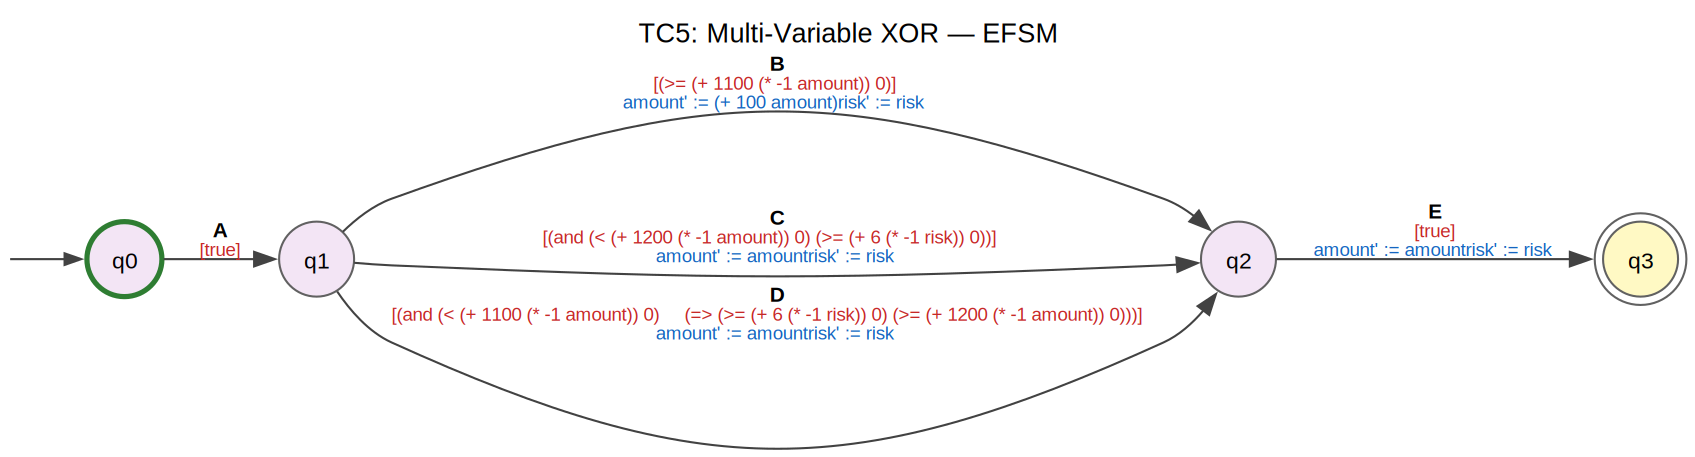

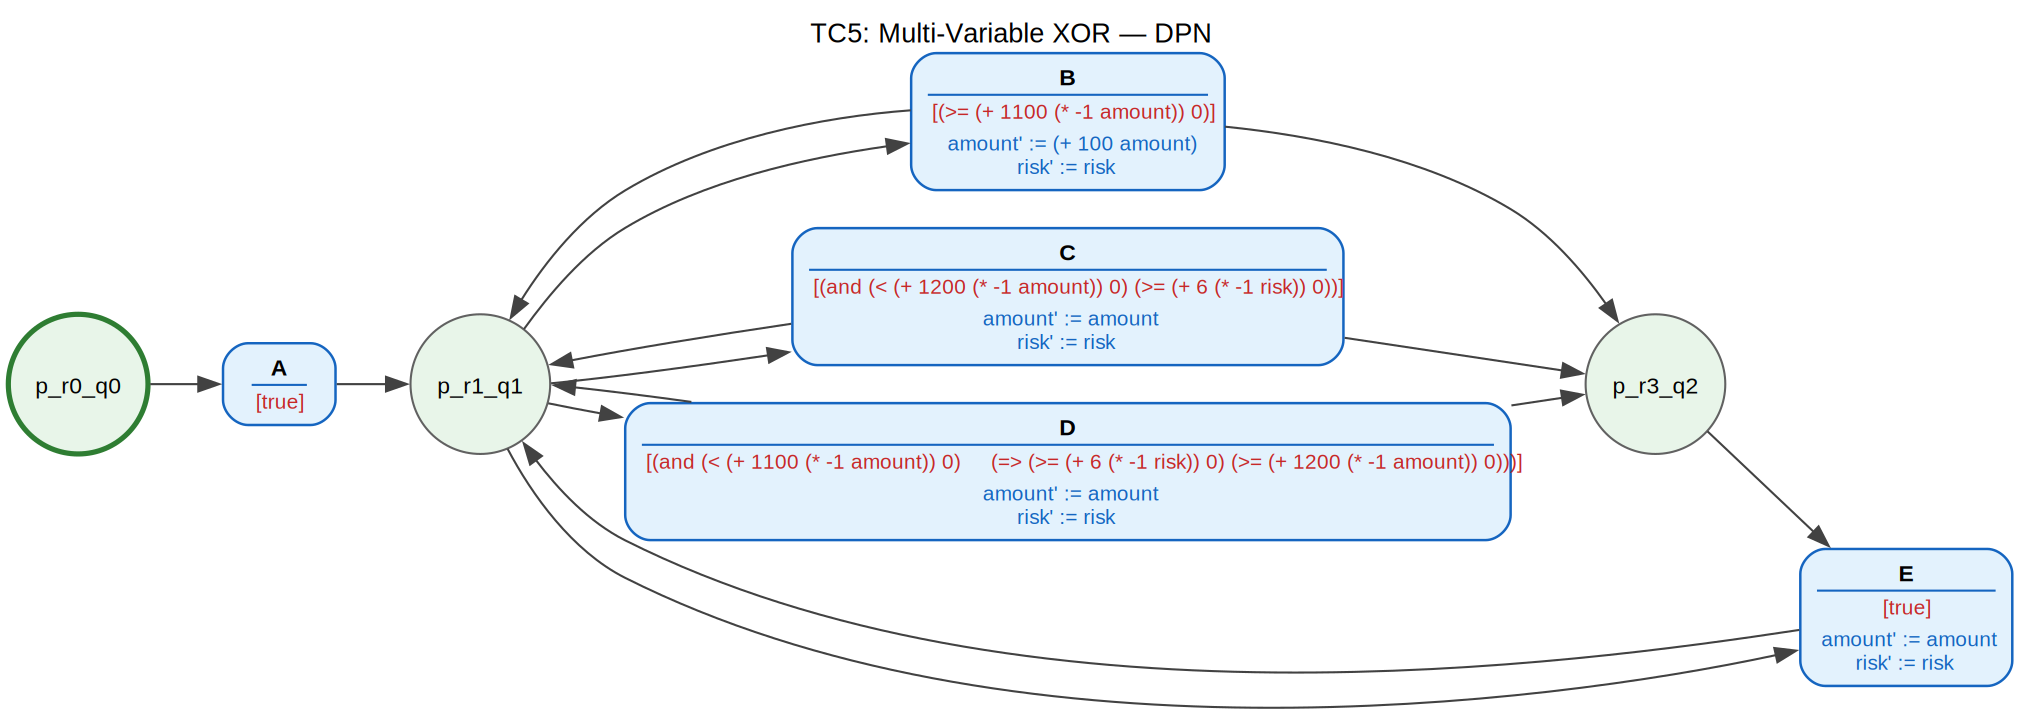

In [28]:
tc5_log = make_log([
    # Branch B: amount <= 1000 → approve (amount += 100 fee)
    [("A", {"amount": 500,  "risk": 2}), ("B", {"amount": 600,  "risk": 2}), ("E", {"amount": 600,  "risk": 2})],
    [("A", {"amount": 200,  "risk": 8}), ("B", {"amount": 300,  "risk": 8}), ("E", {"amount": 300,  "risk": 8})],
    [("A", {"amount": 1000, "risk": 1}), ("B", {"amount": 1100, "risk": 1}), ("E", {"amount": 1100, "risk": 1})],
    # Branch C: amount > 1000 AND risk < 5 → review
    [("A", {"amount": 5000, "risk": 2}), ("C", {"amount": 5000, "risk": 2}), ("E", {"amount": 5000, "risk": 2})],
    [("A", {"amount": 2000, "risk": 4}), ("C", {"amount": 2000, "risk": 4}), ("E", {"amount": 2000, "risk": 4})],
    [("A", {"amount": 1500, "risk": 1}), ("C", {"amount": 1500, "risk": 1}), ("E", {"amount": 1500, "risk": 1})],
    # Branch D: amount > 1000 AND risk >= 5 → reject
    [("A", {"amount": 3000, "risk": 7}), ("D", {"amount": 3000, "risk": 7}), ("E", {"amount": 3000, "risk": 7})],
    [("A", {"amount": 8000, "risk": 9}), ("D", {"amount": 8000, "risk": 9}), ("E", {"amount": 8000, "risk": 9})],
    [("A", {"amount": 1200, "risk": 5}), ("D", {"amount": 1200, "risk": 5}), ("E", {"amount": 1200, "risk": 5})],
])

_, _, tc5_dpn = show_results(
    "TC5: Multi-Variable XOR", tc5_log,
    merge_strategy=MergeStrategy.BLUE_FRINGE, min_merge_score=1,
)

**Expected result:**  
- 3-way XOR split after A, join before E  
- Guard(B) ≈ `amount ≤ 1000`  
- Guard(C) ≈ `amount > 1000 ∧ risk < 5`  
- Guard(D) ≈ `amount > 1000 ∧ risk ≥ 5`  
- Update(B): `amount' := amount + 100`  

---
## TC 6 — Combined: Sequence + XOR + Loop + Updates (★★★★)

**Ground truth:**  
```
                    ┌─ Approve ─┐
  Register → Check ─┤           ├─► Close
        ↑    (loop) └─ Reject ──┘
        └──────┘
           i < 2
```

- **Variables:** `amount` (int), `i` (loop counter)  
- **Guards:**  
  - Check→Check (loop-back): `i < 2`  
  - Check→Approve: `i ≥ 2 ∧ amount ≤ 5000`  
  - Check→Reject:  `i ≥ 2 ∧ amount > 5000`  
- **Updates:**  
  - Register: `i := 0`  
  - Check: `i := i + 1`  
  - Approve: `amount := amount - 50` (processing fee)  

**Purpose:** Stress-test combining loops, XOR branching, and multiple update functions.

INFO     Step 1  >  Using pre-loaded EventLog
INFO              Activities = {'Check', 'Approve', 'Register', 'Close', 'Reject'}  |  Variables = {'i', 'amount'}  |  Traces = 6
INFO     Step 2  >  Classifier training skipped (strategy=BLUE_FRINGE)
INFO     Step 3  >  Building Prefix Tree Acceptor
INFO              States = 8  |  Transitions = 7
INFO     Step 4  >  State merging (strategy=BLUE_FRINGE)
WARNING    Blue-Fringe merging is available but MINT is recommended. Blue-Fringe does not use classifiers and may under-merge.
INFO       Merge loop done: 5 iterations, 2 merges, 8 → 4 states
INFO              States = 8 -> 4  |  Transitions = 7 -> 5
INFO     Step 4b >  Bisimulation-based state reduction
INFO              States = 4 -> 4  |  Transitions = 5
INFO     Step 5  >  Synthesising guards (PHOG-accelerated SAT)
INFO     Guard synthesis: 4 states, 5 transitions, 2 variables
INFO       [2/4] State q1: pairwise cross-activity guards for ['Check', 'Approve', 'Reject']



  TC6: Loop + XOR + Updates
  Traces: 6  |  Activities: {'Check', 'Approve', 'Register', 'Close', 'Reject'}  |  Variables: {'i', 'amount'}



INFO       Partition verified (cross-activity): 3 guards are pairwise disjoint and exhaustive
INFO              Guards synthesised
INFO     Step 6  >  Synthesising postconditions (abduction)
INFO     Postcondition synthesis: 5 transitions, 2 variables
INFO       [1/5] q0 → q1 (Register): 6 observation pairs
INFO       [2/5] q1 → q1 (Check): 12 observation pairs
INFO       [3/5] q1 → q4 (Approve): 3 observation pairs
INFO       [4/5] q4 → q5 (Close): 6 observation pairs
INFO       [5/5] q1 → q4 (Reject): 3 observation pairs
INFO              Postconditions synthesised
INFO     Step 7  >  Region-based EFSM -> DPN (Cortadella et al. S4)
INFO       Region synthesis: |S| = 4, |E| = 5, |T| = 5
INFO         Iteration 1: 3 pre-regions + 3 complements = 6 total regions
INFO         Excitation closure violated for: ['Check'] -- splitting labels
INFO         Iteration 2: 3 pre-regions + 3 complements = 6 total regions
INFO         Excitation closure violated for: ['Check'] -- splitting labels
INF


  PTA  : 8 states, 7 transitions
  EFSM : 4 states, 5 transitions
  DPN  : 3 places, 5 transitions

  Discovered annotations:
    t_Approve_1                     guard = (and (>= (+ 5000 (* -1 amount)) 0) (< (+ 3/2 (* -1 i)) 0))
                                    amount' := (+ -50 amount)
                                    i' := i
    t_Check_2                       guard = (>= (+ 3/2 (* -1 i)) 0)
                                    amount' := amount
                                    i' := (+ 1 i)
    t_Close_3                       guard = true
                                    amount' := amount
                                    i' := i
    t_Register_4                    guard = true
                                    i' := 0
    t_Reject_5                      guard = (and (< (+ 3/2 (* -1 i)) 0)
     (=> (>= (+ 5000 (* -1 amount)) 0) (>= (+ 3/2 (* -1 i)) 0)))
                                    amount' := amount
                                    i' := i



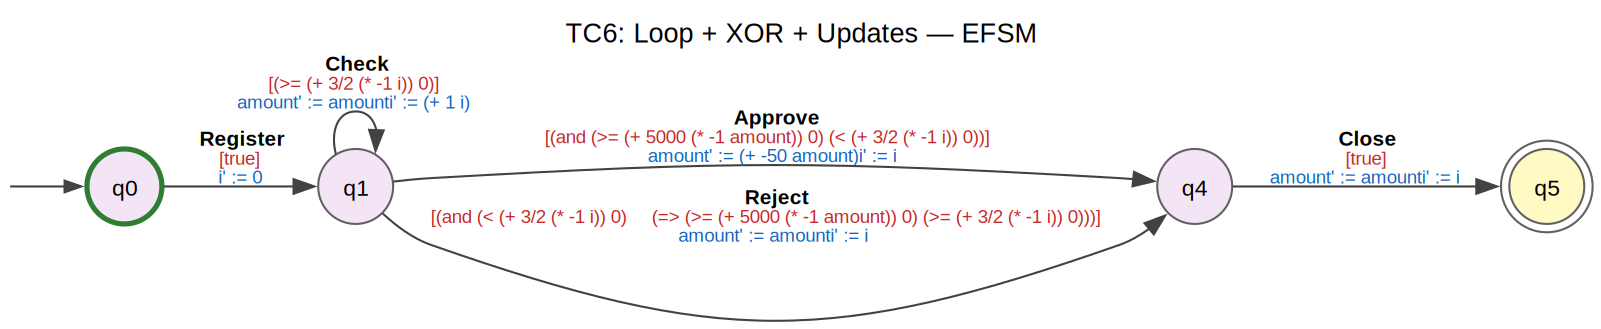

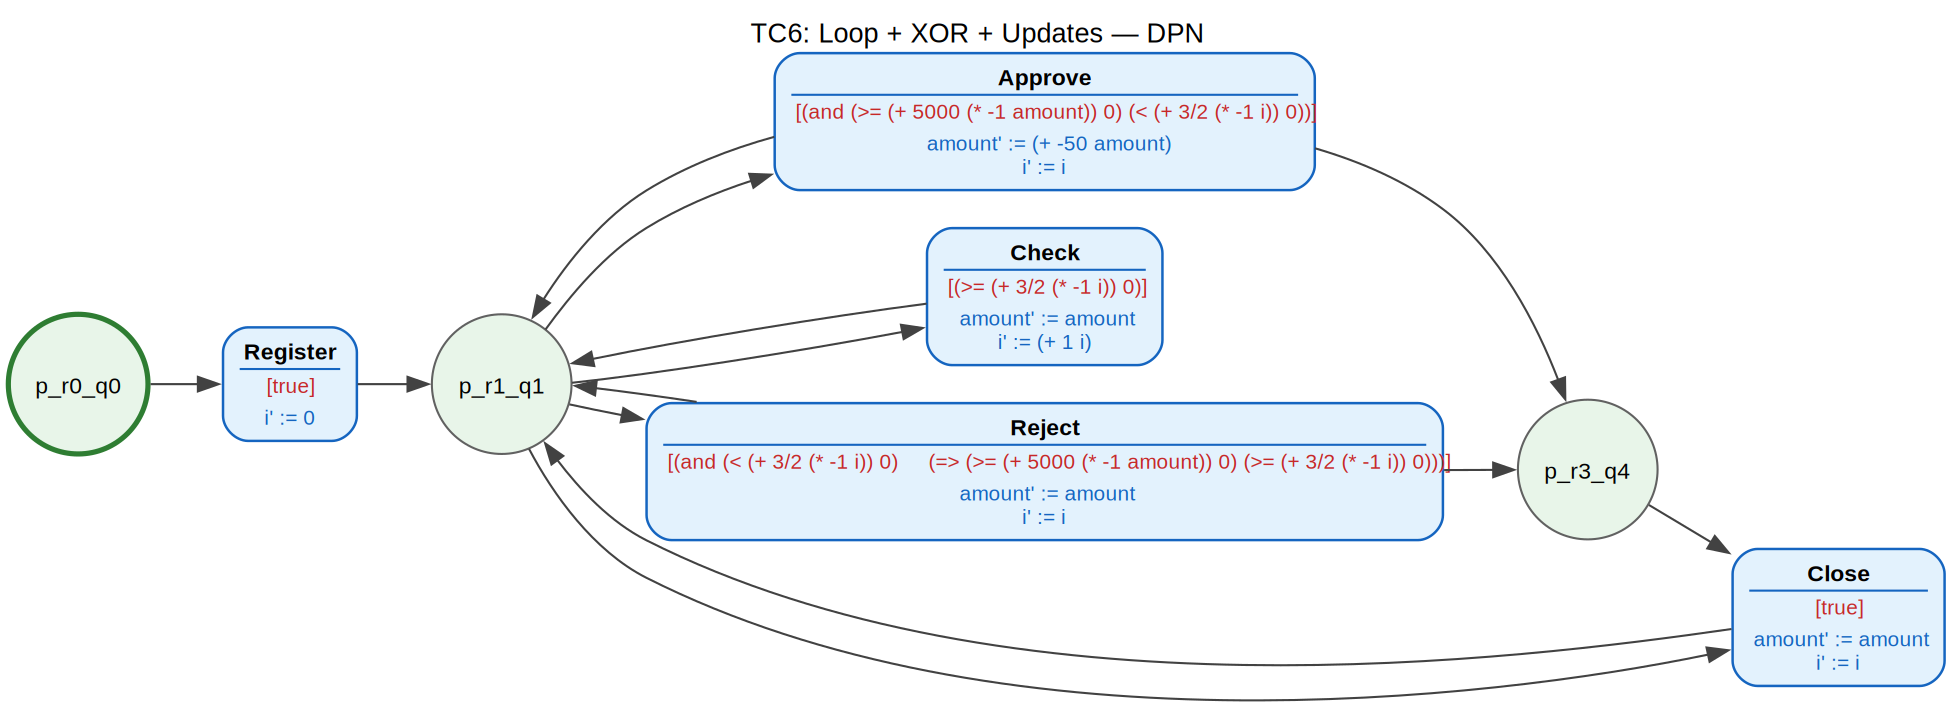

In [29]:
tc6_log = make_log([
    # Loop twice, then approve (amount <= 5000)
    [
        ("Register", {"amount": 1000, "i": 0}),
        ("Check",    {"amount": 1000, "i": 1}),
        ("Check",    {"amount": 1000, "i": 2}),
        ("Approve",  {"amount": 950,  "i": 2}),
        ("Close",    {"amount": 950,  "i": 2}),
    ],
    [
        ("Register", {"amount": 3000, "i": 0}),
        ("Check",    {"amount": 3000, "i": 1}),
        ("Check",    {"amount": 3000, "i": 2}),
        ("Approve",  {"amount": 2950, "i": 2}),
        ("Close",    {"amount": 2950, "i": 2}),
    ],
    [
        ("Register", {"amount": 5000, "i": 0}),
        ("Check",    {"amount": 5000, "i": 1}),
        ("Check",    {"amount": 5000, "i": 2}),
        ("Approve",  {"amount": 4950, "i": 2}),
        ("Close",    {"amount": 4950, "i": 2}),
    ],
    # Loop twice, then reject (amount > 5000)
    [
        ("Register", {"amount": 8000,  "i": 0}),
        ("Check",    {"amount": 8000,  "i": 1}),
        ("Check",    {"amount": 8000,  "i": 2}),
        ("Reject",   {"amount": 8000,  "i": 2}),
        ("Close",    {"amount": 8000,  "i": 2}),
    ],
    [
        ("Register", {"amount": 15000, "i": 0}),
        ("Check",    {"amount": 15000, "i": 1}),
        ("Check",    {"amount": 15000, "i": 2}),
        ("Reject",   {"amount": 15000, "i": 2}),
        ("Close",    {"amount": 15000, "i": 2}),
    ],
    [
        ("Register", {"amount": 6000,  "i": 0}),
        ("Check",    {"amount": 6000,  "i": 1}),
        ("Check",    {"amount": 6000,  "i": 2}),
        ("Reject",   {"amount": 6000,  "i": 2}),
        ("Close",    {"amount": 6000,  "i": 2}),
    ],
])

_, _, tc6_dpn = show_results(
    "TC6: Loop + XOR + Updates", tc6_log,
    merge_strategy=MergeStrategy.BLUE_FRINGE, min_merge_score=1,
)

**Expected result:**  
- Loop on Check (self-loop or cycle)  
- Guard(Check→Check) ≈ `i < 2`  
- Guard(Check→Approve) ≈ `i ≥ 2 ∧ amount ≤ 5000`  
- Guard(Check→Reject) ≈ `i ≥ 2 ∧ amount > 5000`  
- Update(Check): `i' := i + 1`  
- Update(Approve): `amount' := amount - 50`  

---
## Summary & Comparison

In [30]:
import pandas as pd

summary_data = {
    "Test Case": [
        "TC1: Sequence",
        "TC2: XOR Split/Join",
        "TC3: Loop",
        "TC4: Concurrency",
        "TC5: Multi-Var XOR",
        "TC6: Combined",
    ],
    "Traces": [
        len(tc1_log.traces),
        len(tc2_log.traces),
        len(tc3_log.traces),
        len(tc4_log.traces),
        len(tc5_log.traces),
        len(tc6_log.traces),
    ],
    "Variables": [
        len(tc1_log.variables),
        len(tc2_log.variables),
        len(tc3_log.variables),
        len(tc4_log.variables),
        len(tc5_log.variables),
        len(tc6_log.variables),
    ],
    "DPN Places": [
        len(tc1_dpn.places),
        len(tc2_dpn.places),
        len(tc3_dpn.places),
        len(tc4_dpn.places),
        len(tc5_dpn.places),
        len(tc6_dpn.places),
    ],
    "DPN Transitions": [
        len(tc1_dpn.transitions),
        len(tc2_dpn.transitions),
        len(tc3_dpn.transitions),
        len(tc4_dpn.transitions),
        len(tc5_dpn.transitions),
        len(tc6_dpn.transitions),
    ],
    "Control Flow": [
        "Sequence",
        "XOR split/join",
        "Loop",
        "AND split/join",
        "3-way XOR",
        "Loop + XOR",
    ],
    "Complexity": ["★☆☆", "★★☆", "★★☆", "★★★", "★★★", "★★★★"],
}

df_summary = pd.DataFrame(summary_data)
display(HTML("<h3>Evaluation Summary</h3>"))
display(df_summary.to_html(index=False))

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Test Case</th>\n      <th>Traces</th>\n      <th>Variables</th>\n      <th>DPN Places</th>\n      <th>DPN Transitions</th>\n      <th>Control Flow</th>\n      <th>Complexity</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>TC1: Sequence</td>\n      <td>3</td>\n      <td>1</td>\n      <td>4</td>\n      <td>3</td>\n      <td>Sequence</td>\n      <td>★☆☆</td>\n    </tr>\n    <tr>\n      <td>TC2: XOR Split/Join</td>\n      <td>6</td>\n      <td>1</td>\n      <td>3</td>\n      <td>4</td>\n      <td>XOR split/join</td>\n      <td>★★☆</td>\n    </tr>\n    <tr>\n      <td>TC3: Loop</td>\n      <td>4</td>\n      <td>1</td>\n      <td>2</td>\n      <td>3</td>\n      <td>Loop</td>\n      <td>★★☆</td>\n    </tr>\n    <tr>\n      <td>TC4: Concurrency</td>\n      <td>6</td>\n      <td>2</td>\n      <td>6</td>\n      <td>6</td>\n      <td>AND split/join</td>\n      <td>★★★</td>\n    </tr>\n    